# Centrality analysis on the oil trade network from 1988 to 2025

In [151]:
# Importing data

import pandas as pd
df1 = pd.read_csv("data/TradeData_1988_1999.csv", encoding='latin-1', index_col=False)
df2 = pd.read_csv("data/TradeData_2000_2011.csv", encoding='latin-1', index_col=False)
df3 = pd.read_csv("data/TradeData_2012_2023.csv", encoding='latin-1', index_col=False)
df4 = pd.read_csv("data/TradeData_2024_2025.csv", encoding='latin-1', index_col=False)
df_all = pd.concat([df1, df2, df3, df4])

In [152]:
# First we will sort the dataframes by year, then separate the imports from exports. 
# Sometimes, there is a discrepancy between the reported exports of one country and the reported imports of its trade partner.
# If both numbers are available, we will use the figure reported by the importer.
# A directed edge will use the importer as the source and exporter as the target, so the edge direction follows the
# flow of money, not of goods.

start_year=1988
end_year=2026 # The last year of data is 2025 so +1 for indexing
dataframes = {}
imports = {}
exports = {}
all_flows = {}

for year in range(start_year,end_year):
    dataframes[year] = df_all[df_all['refYear'] == year].copy()

for year in range(start_year,end_year):

    imports[year] = dataframes[year][dataframes[year]['flowCode'] == 'M'].copy()
    exports[year] = dataframes[year][dataframes[year]['flowCode'] == 'X'].copy()

    imports[year] = imports[year][['reporterISO', 'partnerISO', 'primaryValue']]
    imports[year].columns = ['source', 'target', 'weight']
    imports[year]['priority'] = 0 

    exports[year] = exports[year][['partnerISO', 'reporterISO', 'primaryValue']]
    exports[year].columns = ['source', 'target', 'weight']
    exports[year]['priority'] = 1  

    all_flows[year] = pd.concat([imports[year], exports[year]])
    
    all_flows[year] = all_flows[year].sort_values('priority')
    all_flows[year] = all_flows[year].drop_duplicates(subset=['source', 'target'], keep='first')
    all_flows[year] = all_flows[year].drop(columns='priority')

# Now turn each year's dataframe into a graph using a new set of dictionaries

import networkx as nx 
trade_graph_dict = {} # digraph

# Nodes which represent broad geographic regions (e.g. World, Areas NES, Other Asia)  will be removed
node_removal = ['W00', '_X ', 'S19', 'XX ', 'X2 ', 'E19', 'F19','A79', 'O19','X1 ', 'ZA1', '_CI', 'A59']

for year in range(start_year,end_year):

    G = nx.from_pandas_edgelist(
        all_flows[year],
        source="source",
        target="target",
        edge_attr="weight",
        create_using=nx.DiGraph()
    )

    G.remove_nodes_from(node_removal)

    trade_graph_dict[year] = G


In [153]:
# A function to prune a graph to the top k partners (#1 country that one imports from)
# The returned graph is directed but UNWEIGHTED

def keep_top_k_neighbors(G, k):
    G_pruned = nx.DiGraph()
    G_pruned.add_nodes_from(G.nodes())
    
    for node in G.nodes():
        # Get all edges from this node with weights
        edges = [(node, neighbor, G[node][neighbor]['weight']) 
                 for neighbor in G.successors(node)]
        
        # Sort by weight descending and take top k
        top_edges = sorted(edges, key=lambda x: x[2], reverse=True)[:k]
        
        # Add to pruned graph
        for u, v, w in top_edges:
            G_pruned.add_edge(u, v)
    
    return G_pruned

def graphdict_to_edgelist(graph_dict):
    
    # Create master dataframe which will contain edges from all years
    dfs = []

    for year, G in graph_dict.items():
        # Create a dataframe out of each year's graph
        df = nx.to_pandas_edgelist(G, edge_key="key")
        # Add the year as a column of that dataframe
        df["year"] = year
        # Append the rows from this dataframe onto the master dataframe containing all years
        dfs.append(df)

    # Now return this master dataframe
    return pd.concat(dfs, ignore_index=True)
    # And write it to a csv file
    #full_pruned_imports_edge_df.to_csv("/Users/kynesantos/Grad School/Trade Networks/Total Trade 2012-2023/importer network.csv", index=False)


In [154]:
# Saving the pruned (unweighted) graph and the full (weighted) graph

pruned_dict_k3 = {}
pruned_dict_k1 = {}

for year in range(start_year, end_year):
    pruned_dict_k3[year] = keep_top_k_neighbors(trade_graph_dict[year], k=3)
    pruned_dict_k1[year] = keep_top_k_neighbors(trade_graph_dict[year], k=1)

pruned_trade_graph_k3 = graphdict_to_edgelist(pruned_dict_k3)
pruned_trade_graph_k1 = graphdict_to_edgelist(pruned_dict_k1)
#pruned_trade_graph_k3.to_csv("data/Oil Trade k3 graph.csv", index=False)

full_oil_trade_graph = graphdict_to_edgelist(trade_graph_dict)
full_oil_trade_graph.to_csv("data/Oil Trade full graph.csv", index=False)
    

In [155]:
# Making the statistics table which shows, for each year, the top 5 (k) countries sorted by:
# Pagerank and weighted in degree centrality.
# For each year, the number of edges, nodes, clustering, number of connected components, and average path length
# is also listed.

pageranks = {}
wgt_in_degree = {}

num_nodes = {}
num_edges = {}
num_connectedcomponents = {}
LKL = {}

def weighted_indegree(G):
    return {u: G.in_degree(u, weight='weight') for u in G.nodes()}

def weighted_indegree_centrality(G):
    normalization_factor = sum(weighted_indegree(G).values())
    return {u: (weighted_indegree(G)[u] / normalization_factor) for u in G.nodes }

def safe_avgpathlength(G):
    
    components = nx.number_connected_components(G)
    average = 0

    for C in (G.subgraph(c).copy() for c in nx.connected_components(G)):
        print(nx.average_shortest_path_length(C), C.number_of_nodes()) 
        average += (nx.average_shortest_path_length(C)) * (C.number_of_nodes() / G.number_of_nodes())
    
    print("Average = %s" % average)
    return average

# This function makes a stat table given a graph dictionary and index range
def stat_table_maker(graph_dict, startyear, endyear, k):

    for year in range(startyear, endyear):
        wgt_in_degree[year] = weighted_indegree_centrality(graph_dict[year])
        pageranks[year] = nx.pagerank(graph_dict[year])
        
        centrality_maps = {
        "pagerank": pageranks,
        "weighted in degree": wgt_in_degree,
        }

    rows = {}

    for name, yearly_scores in centrality_maps.items():
        rows[name] = {
            year: [k for k, _ in sorted(scores.items(),
                                   key=lambda x: x[1],
                                   reverse=True)[:k]] if scores else None
        for year, scores in yearly_scores.items()
        }

    rows['clustering'] = {year: nx.average_clustering(graph_dict[year]) for year in range(startyear, endyear)}
    rows['# nodes'] = {year: graph_dict[year].number_of_nodes() for year in range(startyear, endyear)}
    rows['# edges'] = {year: graph_dict[year].number_of_edges() for year in range(startyear, endyear)}
    rows['# of connected components'] = {year: nx.number_connected_components(graph_dict[year].to_undirected()) for year in range(startyear, endyear)}
    rows['Average path length'] = {year: safe_avgpathlength(graph_dict[year].to_undirected()) for year in range(startyear, endyear)}

    stat_table = pd.DataFrame(rows).T.sort_index(axis=1)

    return stat_table

In [156]:
stat_table = stat_table_maker(trade_graph_dict, start_year, end_year, k=5)
stat_table.to_csv("data/Oil Trade stat table.csv")

2.431638418079096 60
Average = 2.431638418079096
2.45981981981982 75
Average = 2.45981981981982
2.4946778711484594 85
0 1
Average = 2.4656699889258027
2.481329350261389 104
Average = 2.481329350261389
2.524737631184408 116
0 1
Average = 2.503158677071721
2.6606791338582676 128
0 1
0 1
Average = 2.6197456087219866
2.555174603174603 126
0 1
0 1
0 1
0 1
0 1
0 1
1.0 2
Average = 2.4175522388059703
2.567983789260385 141
0 1
0 1
0 1
0 1
Average = 2.497142857142857
2.4699233716475097 145
0 1
0 1
0 1
0 1
0 1
0 1
0 1
Average = 2.3561769005847957
2.5238095238095237 154
0 1
0 1
0 1
0 1
0 1
0 1
0 1
0 1
0 1
0 1
Average = 2.3699186991869916
2.5080213903743314 154
0 1
0 1
Average = 2.475867269984917
2.43904052936311 156
0 1
0 1
1.0 2
0 1
0 1
0 1
0 1
0 1
0 1
Average = 2.3041585697629228
2.5376310338334065 179
0 1
Average = 2.523533083645443
2.4966933518969716 170
Average = 2.4966933518969716
2.471192682347351 184
Average = 2.471192682347351
2.47298927188472 178
Average = 2.47298927188472
2.533083867902

In [157]:
# Identifying the top 20 countries by oil exports in 2024
sorted_degree = dict(sorted(wgt_in_degree[2024].items(), key=lambda x: x[1], reverse=True)[:20])
topexporters = list(sorted_degree.keys())
topexporters

['SAU',
 'RUS',
 'USA',
 'CAN',
 'ARE',
 'IRQ',
 'BRA',
 'NOR',
 'MYS',
 'NGA',
 'KAZ',
 'AGO',
 'KWT',
 'LBY',
 'OMN',
 'MEX',
 'NLD',
 'GUY',
 'QAT',
 'COL']

# Plots

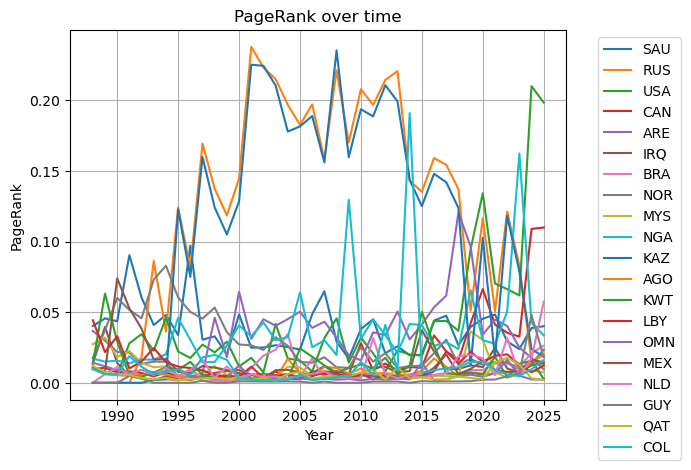

In [158]:
import matplotlib.pyplot as plt

years = [i for i in range(start_year,end_year)]
pagerank_data = {c: [pageranks[year].get(c, 0.0) for year in years] for c in topexporters}

for c in topexporters:
    plt.plot(years, pagerank_data[c], label=c)

plt.xlabel("Year")
plt.ylabel("PageRank")
plt.title("PageRank over time")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

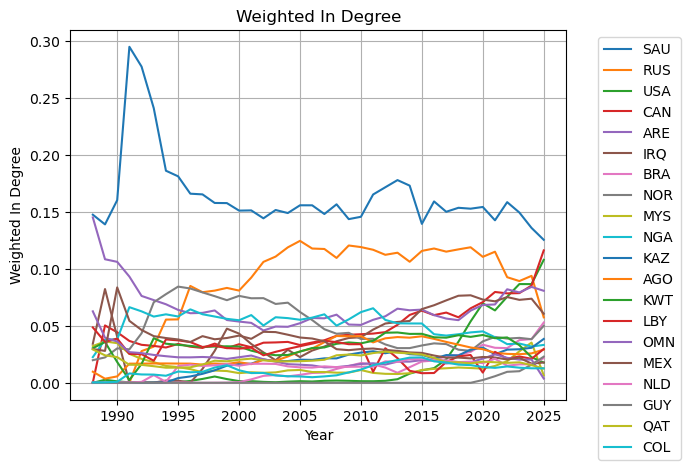

In [159]:

indegree_data = {c: [wgt_in_degree[year].get(c, 0.0) for year in years] for c in topexporters}

for c in topexporters:
    plt.plot(years, indegree_data[c], label=c)

plt.xlabel("Year")
plt.ylabel("Weighted In Degree")
plt.title("Weighted In Degree")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# Computing Spearman Correlations

To what degree does the oil trade hierarchy reshuffle each year?

In [160]:
pagerank_df = pd.DataFrame.from_dict(pageranks)
wgt_in_degree_df =  pd.DataFrame.from_dict(wgt_in_degree)

top20pagerank_df = pagerank_df.loc[topexporters].copy()
top20wid_df = wgt_in_degree_df.loc[topexporters].copy()

top20pagerankmatrix  = top20pagerank_df.corr(method='spearman')
top20WIDmatrix  = top20wid_df.corr(method='spearman')

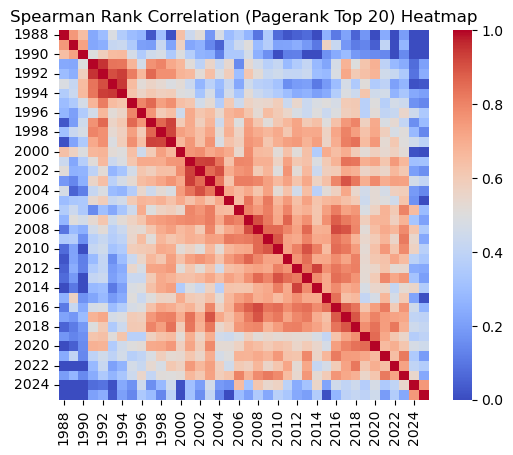

In [161]:
sns.heatmap(top20pagerankmatrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (Pagerank Top 20) Heatmap")
plt.show()

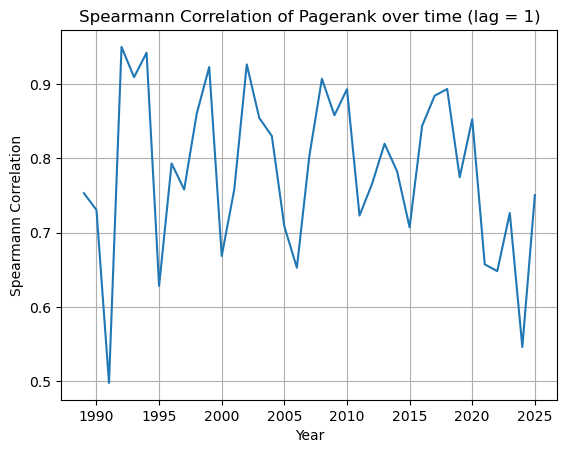

In [162]:
lag = 1 # space between years we want to compare

years = [i for i in range(start_year+lag, end_year)]

data_pagerank = [top20pagerankmatrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_pagerank)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of Pagerank over time (lag = {lag})")
plt.grid(True)
plt.show()

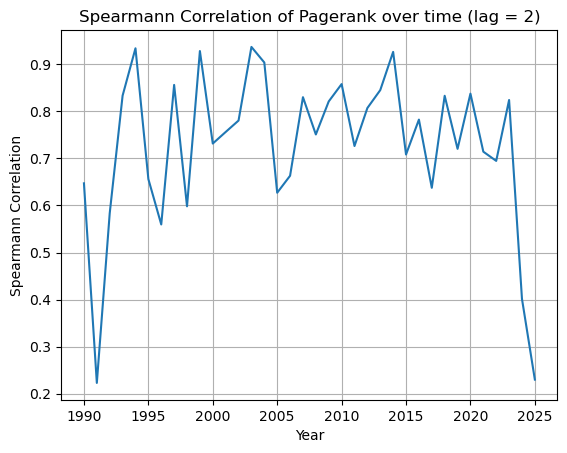

In [163]:
lag = 2 # space between years we want to compare

years = [i for i in range(start_year+lag, end_year)]

data_pagerank = [top20pagerankmatrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_pagerank)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of Pagerank over time (lag = {lag})")
plt.grid(True)
plt.show()

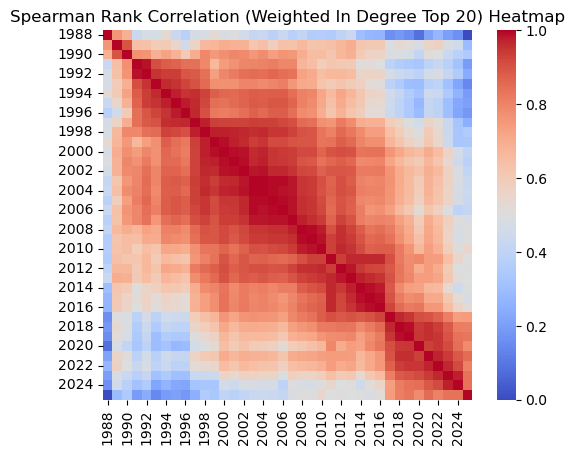

In [164]:
sns.heatmap(top20WIDmatrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (Weighted In Degree Top 20) Heatmap")
plt.show()

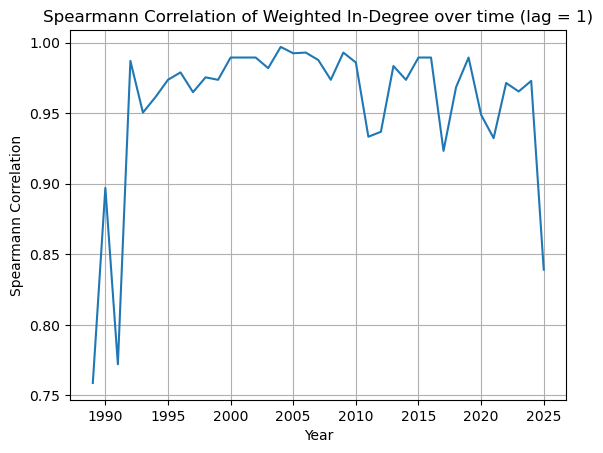

In [165]:
lag = 1 # space between years we want to compare

years = [i for i in range(start_year+lag, end_year)]

data_wid = [top20WIDmatrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_wid)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of Weighted In-Degree over time (lag = {lag})")
plt.grid(True)
plt.show()

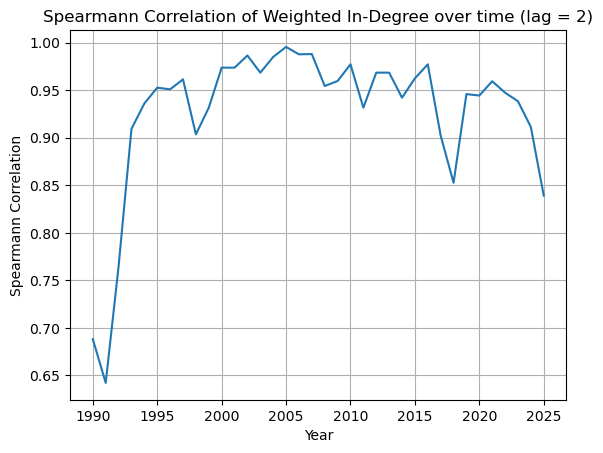

In [166]:
lag = 2 # space between years we want to compare

years = [i for i in range(start_year+lag, end_year)]

data_wid = [top20WIDmatrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_wid)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of Weighted In-Degree over time (lag = {lag})")
plt.grid(True)
plt.show()